# Sentiment Analysis using Naïve Bayes

This notebook demonstrates **sentiment analysis** on the IMDB Movie Reviews dataset using three Naïve Bayes variants:

- **GaussianNB** — assumes Gaussian-distributed features
- **MultinomialNB** — suited for word count features
- **BernoulliNB** — suited for binary word presence

### Pipeline:
1. Load and sample the IMDB dataset
2. Text preprocessing (HTML removal, lowercasing, stopword removal, stemming)
3. Feature extraction using Bag of Words (CountVectorizer)
4. Train-test split and model training
5. Model comparison and evaluation
6. Laplace smoothing (alpha) tuning

> **Theory notebook:** See [`02-naive-bayes-from-scratch.ipynb`](02-naive-bayes-from-scratch.ipynb) for Bayes' theorem, the Naïve Bayes formula, and a from-scratch implementation.

---
## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import re
import os
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords', quiet=True)
print("All libraries imported successfully!")

All libraries imported successfully!


---
## 2. Load the IMDB Dataset

In [15]:
df_imdb = pd.read_csv('../../datasets/IMDB Dataset.csv')
df_imdb.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# Sample 10,000 rows for efficiency
df_imdb = df_imdb.sample(10000, random_state=42).reset_index(drop=True)
print(f"Sampled dataset shape: {df_imdb.shape}")

# Encode sentiment: positive -> 1, negative -> 0
df_imdb['sentiment'] = df_imdb['sentiment'].map({'positive': 1, 'negative': 0})

print(f"\nSentiment distribution:")
print(df_imdb['sentiment'].value_counts())

print(f"\nSample review (before cleaning):")
print(df_imdb['review'][0][:300])

Sampled dataset shape: (10000, 2)

Sentiment distribution:
sentiment
1    5039
0    4961
Name: count, dtype: int64

Sample review (before cleaning):
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok 


---
## 3. Text Preprocessing

### Pipeline:
1. Remove HTML tags
2. Convert to lowercase
3. Remove special characters
4. Remove stopwords (NLTK)
5. Apply Porter Stemming
6. Join tokens back

In [4]:
def clean_html(text):
    """Remove HTML tags."""
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

def convert_lower(text):
    return text.lower()

def remove_special(text):
    result = ''
    for char in text:
        if char.isalnum():
            result += char
        else:
            result += ' '
    return result

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return [word for word in text.split() if word not in stop_words]

def stem_words(word_list):
    return [ps.stem(word) for word in word_list]

def join_back(word_list):
    return " ".join(word_list)

print("Text cleaning functions defined.")

Text cleaning functions defined.


In [5]:
print("Applying text preprocessing pipeline...")

df_imdb['review'] = df_imdb['review'].apply(clean_html)
print("  Done: HTML tags removed")

df_imdb['review'] = df_imdb['review'].apply(convert_lower)
print("  Done: Converted to lowercase")

df_imdb['review'] = df_imdb['review'].apply(remove_special)
print("  Done: Special characters removed")

df_imdb['review'] = df_imdb['review'].apply(remove_stopwords)
print("  Done: Stopwords removed")

df_imdb['review'] = df_imdb['review'].apply(stem_words)
print("  Done: Porter stemming applied")

df_imdb['review'] = df_imdb['review'].apply(join_back)
print("  Done: Tokens joined back into strings")

print(f"\nSample cleaned review:")
print(df_imdb['review'][0][:300])

Applying text preprocessing pipeline...
  Done: HTML tags removed
  Done: Converted to lowercase
  Done: Special characters removed
  Done: Stopwords removed
  Done: Porter stemming applied
  Done: Tokens joined back into strings

Sample cleaned review:
realli like summerslam due look arena curtain look overal interest reason anyway could one best summerslam ever wwf lex luger main event yokozuna time ok huge fat man vs strong man glad time chang terribl main event like everi match luger terribl match card razor ramon vs ted dibias steiner brother 


---
## 4. Feature Extraction — Bag of Words

We use **CountVectorizer** to convert cleaned text into a numerical **Bag of Words** matrix.

In [6]:
cv = CountVectorizer(max_features=2500)
X_bow = cv.fit_transform(df_imdb['review']).toarray()
y_sentiment = df_imdb['sentiment'].values

print(f"Bag of Words matrix shape: {X_bow.shape}")
print(f"  -> {X_bow.shape[0]} reviews x {X_bow.shape[1]} vocabulary words")
print(f"\nSample feature names: {cv.get_feature_names_out()[:20].tolist()}")
print(f"\nSparsity: {(X_bow == 0).sum() / X_bow.size * 100:.2f}% zeros")

Bag of Words matrix shape: (10000, 2500)
  -> 10000 reviews x 2500 vocabulary words

Sample feature names: ['000', '10', '100', '11', '12', '13', '15', '1930', '1940', '1950', '1960', '1970', '1980', '20', '2001', '25', '30', '40', '50', '60']

Sparsity: 96.99% zeros


---
## 5. Train-Test Split & Model Training

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bow, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (8000, 2500)
Test set:     (2000, 2500)


In [8]:
clf_gaussian = GaussianNB()
clf_multinomial = MultinomialNB()
clf_bernoulli = BernoulliNB()

clf_gaussian.fit(X_train, y_train)
clf_multinomial.fit(X_train, y_train)
clf_bernoulli.fit(X_train, y_train)

print("All three Naive Bayes models trained!")

All three Naive Bayes models trained!


---
## 6. Model Comparison

In [9]:
y_pred_gauss = clf_gaussian.predict(X_test)
y_pred_multi = clf_multinomial.predict(X_test)
y_pred_bern  = clf_bernoulli.predict(X_test)

acc_gauss = accuracy_score(y_test, y_pred_gauss)
acc_multi = accuracy_score(y_test, y_pred_multi)
acc_bern  = accuracy_score(y_test, y_pred_bern)

print("=" * 55)
print(f"{'Model':<20} {'Accuracy':>10}")
print("=" * 55)
print(f"{'GaussianNB':<20} {acc_gauss:>10.4f}")
print(f"{'MultinomialNB':<20} {acc_multi:>10.4f}")
print(f"{'BernoulliNB':<20} {acc_bern:>10.4f}")
print("=" * 55)

best_model = max(
    [('GaussianNB', acc_gauss), ('MultinomialNB', acc_multi), ('BernoulliNB', acc_bern)],
    key=lambda x: x[1]
)
print(f"\nBest model: {best_model[0]} with accuracy {best_model[1]:.4f}")

Model                  Accuracy
GaussianNB               0.7225
MultinomialNB            0.8190
BernoulliNB              0.8365

Best model: BernoulliNB with accuracy 0.8365


### Why MultinomialNB & BernoulliNB outperform GaussianNB on text:

- **GaussianNB** assumes continuous Gaussian features. Word counts are discrete, sparse, and non-negative — violating this assumption.
- **MultinomialNB** is designed for count data, making it a natural fit for Bag of Words.
- **BernoulliNB** models binary word presence/absence, matching text sparsity.

> **Rule of thumb:** For text classification, prefer **MultinomialNB** (word counts/TF-IDF) or **BernoulliNB** (binary).

---
## 7. Evaluate Model Performance

In [10]:
models = {
    'GaussianNB': y_pred_gauss,
    'MultinomialNB': y_pred_multi,
    'BernoulliNB': y_pred_bern
}

metrics_data = []
for name, y_pred in models.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    metrics_data.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                         'Recall': rec, 'F1-Score': f1})

df_metrics = pd.DataFrame(metrics_data).set_index('Model')
print("Detailed Performance Metrics:")
print(df_metrics.round(4).to_string())

Detailed Performance Metrics:
               Accuracy  Precision  Recall  F1-Score
Model                                               
GaussianNB       0.7225     0.7814  0.6240    0.6939
MultinomialNB    0.8190     0.8198  0.8214    0.8206
BernoulliNB      0.8365     0.8290  0.8512    0.8399


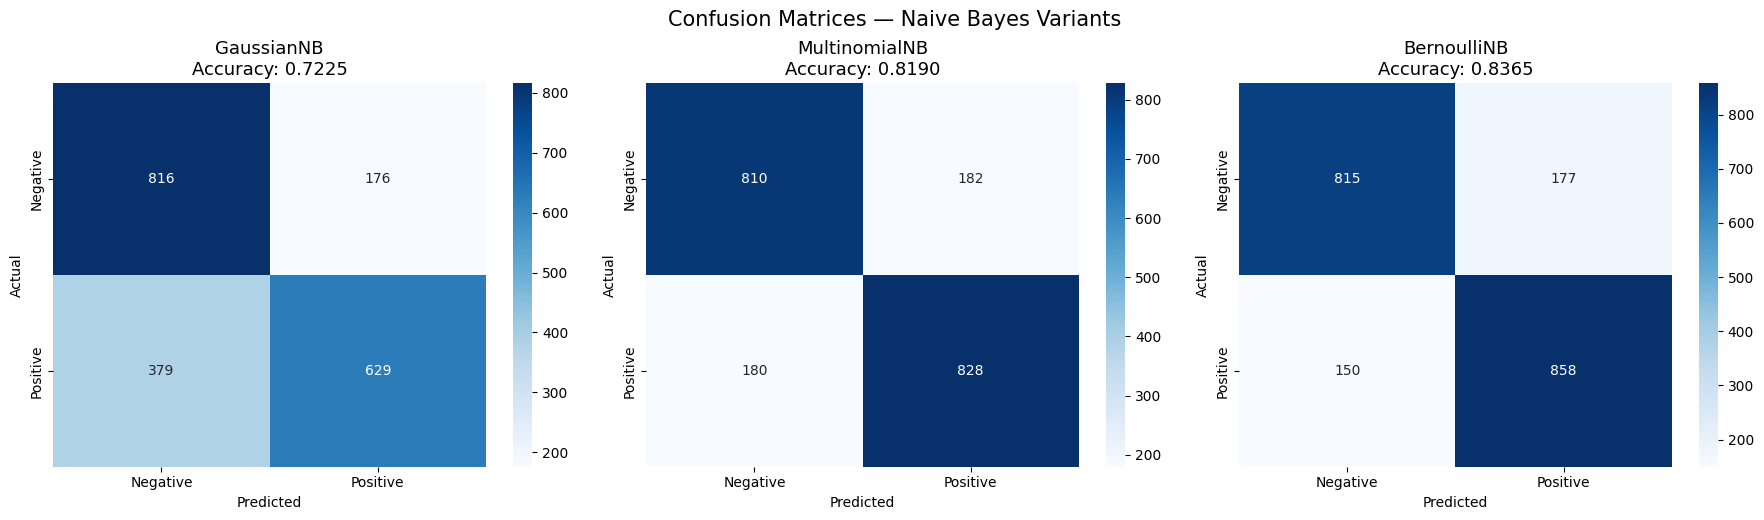

In [11]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}', fontsize=13)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.suptitle('Confusion Matrices — Naive Bayes Variants', y=1.03, fontsize=15)
plt.show()

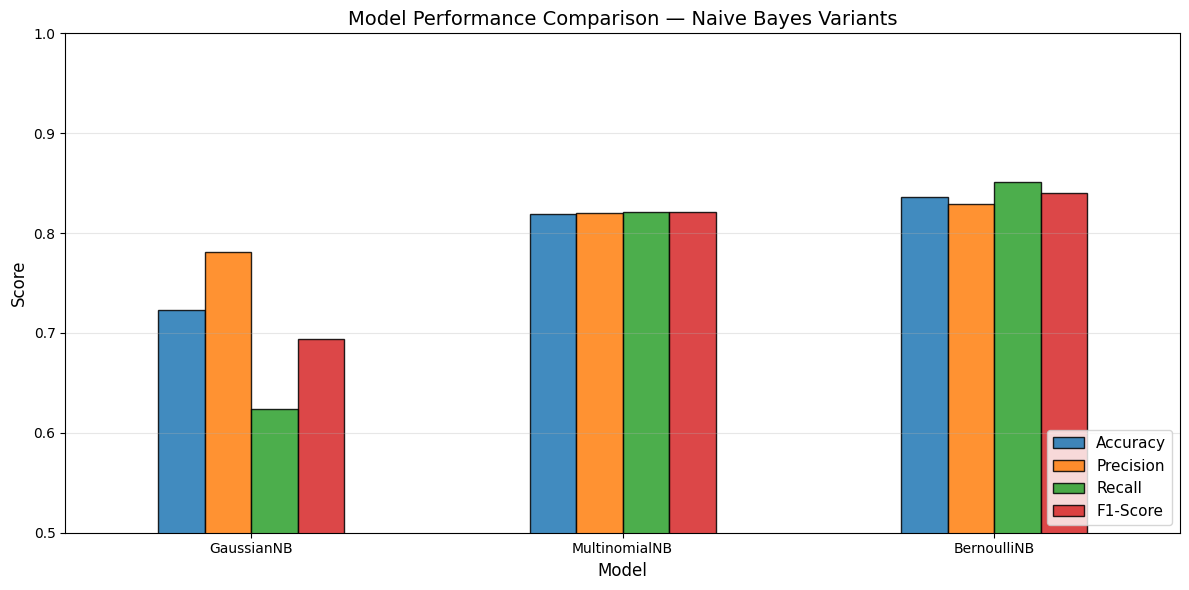

In [12]:
# Bar chart comparison
df_metrics.plot(kind='bar', figsize=(12, 6), edgecolor='black', alpha=0.85)
plt.title('Model Performance Comparison — Naive Bayes Variants', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Classification reports
for name, y_pred in models.items():
    print(f"\n{'='*55}")
    print(f"Classification Report — {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


Classification Report — GaussianNB
              precision    recall  f1-score   support

    Negative       0.68      0.82      0.75       992
    Positive       0.78      0.62      0.69      1008

    accuracy                           0.72      2000
   macro avg       0.73      0.72      0.72      2000
weighted avg       0.73      0.72      0.72      2000


Classification Report — MultinomialNB
              precision    recall  f1-score   support

    Negative       0.82      0.82      0.82       992
    Positive       0.82      0.82      0.82      1008

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000


Classification Report — BernoulliNB
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83       992
    Positive       0.83      0.85      0.84      1008

    accuracy                           0.84      2000
   macro avg    

---
## 8. Laplace Smoothing — Alpha Tuning

The `alpha` hyperparameter in MultinomialNB controls **Laplace smoothing**. Let's find the optimal value.

  alpha=0.001  -> Accuracy: 0.8190
  alpha=0.01   -> Accuracy: 0.8190
  alpha=0.1    -> Accuracy: 0.8190
  alpha=0.5    -> Accuracy: 0.8190
  alpha=1.0    -> Accuracy: 0.8190
  alpha=2.0    -> Accuracy: 0.8195
  alpha=5.0    -> Accuracy: 0.8210
  alpha=10.0   -> Accuracy: 0.8225


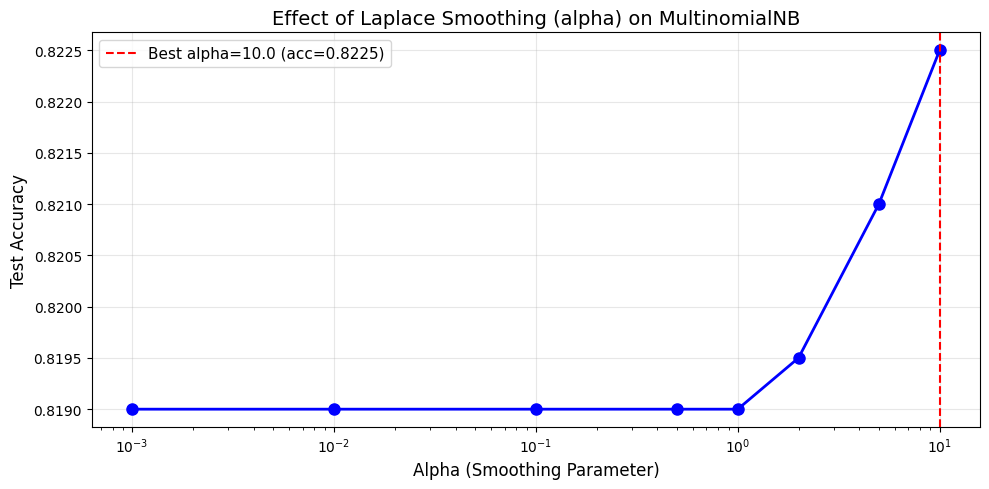


Best alpha: 10.0 with accuracy 0.8225


In [14]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
results = []

for alpha in alphas:
    clf = MultinomialNB(alpha=alpha)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'alpha': alpha, 'accuracy': acc})
    print(f"  alpha={alpha:<6} -> Accuracy: {acc:.4f}")

df_alpha = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
plt.plot(df_alpha['alpha'], df_alpha['accuracy'], 'bo-', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Alpha (Smoothing Parameter)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Effect of Laplace Smoothing (alpha) on MultinomialNB', fontsize=14)
plt.grid(True, alpha=0.3)
best_alpha = df_alpha.loc[df_alpha['accuracy'].idxmax()]
plt.axvline(x=best_alpha['alpha'], color='red', linestyle='--',
            label=f"Best alpha={best_alpha['alpha']} (acc={best_alpha['accuracy']:.4f})")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nBest alpha: {best_alpha['alpha']} with accuracy {best_alpha['accuracy']:.4f}")

---
## Summary

- **MultinomialNB** and **BernoulliNB** are better suited for text classification than GaussianNB
- Text preprocessing (HTML removal, lowercasing, stopword removal, stemming) significantly impacts model quality
- **Laplace smoothing** (`alpha`) is a key hyperparameter — tune it for optimal performance
- The **Bag of Words** representation with `CountVectorizer` provides a simple but effective feature extraction method

> For the mathematical theory behind Naive Bayes, see [`02-naive-bayes-from-scratch.ipynb`](02-naive-bayes-from-scratch.ipynb)